In [9]:
# linear algebra
import numpy as np

# data processing
import pandas as pd

# data visualization
import seaborn as sns
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import style
from sklearn.metrics import confusion_matrix

# Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline

In [10]:
df = pd.read_csv("/content/email.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [11]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


**Catagorized the Dataframe**

In [14]:
df['spam']=df['Category'].apply(lambda x: 1 if x=='spam' else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
X=df['Message']
Y=df['spam']

In [16]:
#train-test-split dataset
X_train, X_test, y_train, y_test = train_test_split(X,Y)

**create classifier for naive baised**

In [17]:
#Defineing Naive Baised
clf_NaiveBaised= Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nd', MultinomialNB())
])

In [18]:
#Fiting the algorithm
clf_NaiveBaised.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nd', MultinomialNB())])

In [19]:
#Make prediction on X_test
y_pred_NB=clf_NaiveBaised.predict(X_test)

In [20]:
conf_mat_NB=confusion_matrix(y_test, y_pred_NB)

<Axes: >

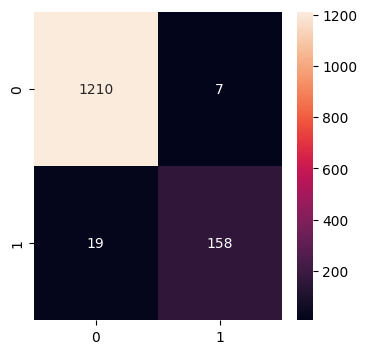

In [21]:
#plot confusion matrix
plt.figure(figsize=(4,4))
sns.heatmap(conf_mat_NB,annot=True,fmt='d')

In [22]:
naive_acc=accuracy_score(y_test,y_pred_NB)
naive_acc

0.9813486370157819

In [23]:
#create classifier for support vector machine
clf_svm= Pipeline([
    ('vectorizer', CountVectorizer()),
    ('svc', SVC(kernel="rbf",C=1000,gamma=0.001))
])

In [24]:
clf_svm.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('svc', SVC(C=1000, gamma=0.001))])

In [25]:
y_pred_SVM=clf_svm.predict(X_test)

In [26]:
#plot confusion matrix
conf_mat_SVM=confusion_matrix(y_test, y_pred_SVM)

<Axes: >

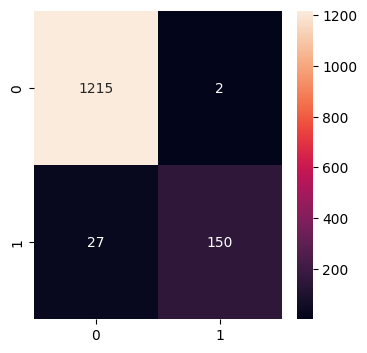

In [27]:
plt.figure(figsize=(4,4))
sns.heatmap(conf_mat_SVM,annot=True,fmt='d')

In [28]:
svm_acc=accuracy_score(y_test,y_pred_SVM)
svm_acc

0.9791965566714491

In [29]:
#Create Classifier for DecisionTreeClassifier
clf_DecisionTree= Pipeline([
    ('vectorizer', CountVectorizer()),
    ('dt',DecisionTreeClassifier())
])

In [30]:
clf_DecisionTree.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('dt', DecisionTreeClassifier())])

In [31]:
y_pred_DT=clf_DecisionTree.predict(X_test)

In [32]:
#plot confusion matrix
conf_mat_DT=confusion_matrix(y_test, y_pred_DT)

<Axes: >

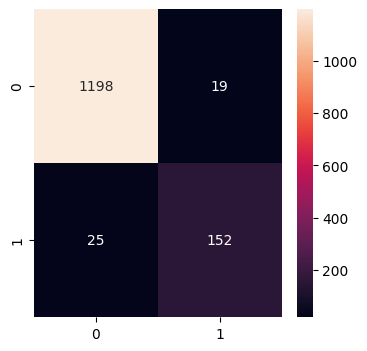

In [33]:
plt.figure(figsize=(4,4))
sns.heatmap(conf_mat_DT,annot=True,fmt='d')

In [34]:
dt_acc=accuracy_score(y_test,y_pred_DT)
dt_acc

0.9684361549497847

In [35]:
#RANDOM FOREST CLASSIFIER
clf_rf= Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', RandomForestClassifier(n_estimators=100))
])

In [36]:
clf_rf.fit(X_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('rf', RandomForestClassifier())])

In [37]:
y_pred_RF=clf_rf.predict(X_test)

In [38]:
#plot confusion matrix
conf_mat_RF=confusion_matrix(y_test, y_pred_RF)

<Axes: >

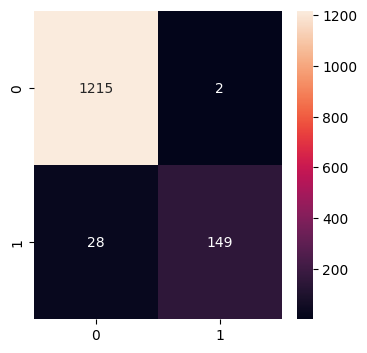

In [39]:
plt.figure(figsize=(4,4))
sns.heatmap(conf_mat_RF,annot=True,fmt='d')

In [40]:
rf_acc=accuracy_score(y_test,y_pred_RF)
rf_acc

0.9784791965566715

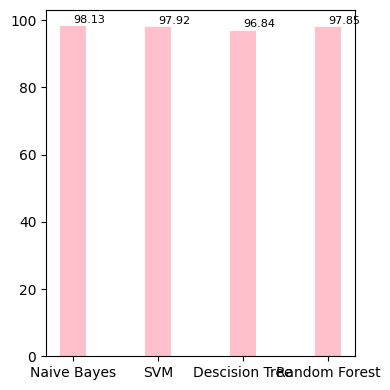

In [42]:
#comparing accuracy of those algorithtims
menMeans = np.array([naive_acc,svm_acc,dt_acc,rf_acc])*100
ind = ['Naive Bayes','SVM','Descision Tree','Random Forest']
fig, ax = plt.subplots(figsize = (4,4))
ax.bar(ind,menMeans,width=0.3,color ='pink')
for index,data in enumerate(menMeans):
    plt.text(x=index , y =data+1 , s="{:.2f}".format(data) , fontdict=dict(fontsize=8))
plt.tight_layout()
plt.show()

**testing this model with custom email**

In [44]:
#Function for testing custome email
def spam_dect(clf,txt):
    a=clf.predict([txt])
    if a==1:
        print("This is a Spam email")
    else:
        print("This is a Real email")

**Demonstrates:
Spam detection works on unseen data
Real-world applicability**

In [46]:
#Demo email
test_email_1="Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!" #Spam Email from my mail box
test_email_2="Hey Ashfak, can we get together to watch footbal game tomorrow?"   #Real Email from my mail box

In [47]:
#Predict with Naive Bayes
spam_dect(clf_NaiveBaised,test_email_1)

This is a Spam email


In [48]:
#Predict with Naive Bayes
spam_dect(clf_NaiveBaised,test_email_2)

This is a Real email


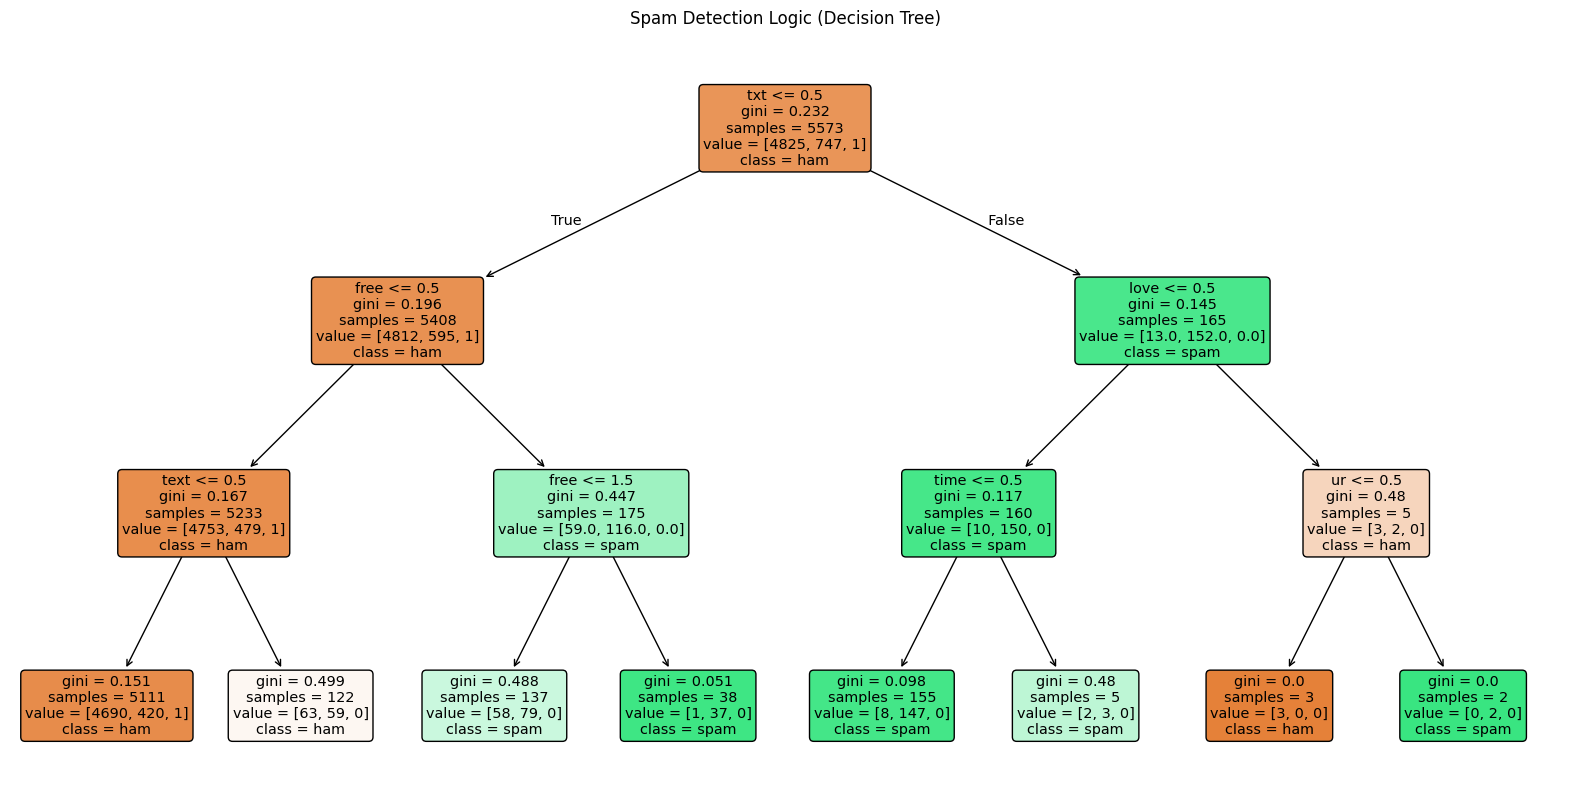

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# 1. Load the Email Dataset
df = pd.read_csv('email.csv')

# 2. Encode Labels (Ham = 0, Spam = 1)
le = LabelEncoder()
y = le.fit_transform(df['Category'])

# 3. Vectorize Text (Translator)
# We pick the top 20 most frequent words to keep the tree simple
vectorizer = CountVectorizer(max_features=20, stop_words='english')
X = vectorizer.fit_transform(df['Message'])

# 4. Train the Decision Tree
# We limit max_depth=3 so we can actually read the visual output
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X, y)

# 5. Visualizing the Tree
plt.figure(figsize=(20,10))
plot_tree(dt,
          feature_names=vectorizer.get_feature_names_out(),
          class_names=le.classes_,
          filled=True,
          rounded=True)
plt.title("Spam Detection Logic (Decision Tree)")
plt.savefig('email_decision_tree.png')

Spam Email Classification using Machine Learning

Developed an end-to-end machine learning model to classify emails as spam or ham using natural language processing techniques. The dataset was preprocessed by converting categorical labels into numerical form and transforming text data into feature vectors using CountVectorizer. Multiple classification algorithms, including Naive Bayes, Support Vector Machine (SVM), Decision Tree, and Random Forest, were implemented and evaluated using accuracy and confusion matrix.

The models were compared to identify the best-performing algorithm for text classification, with Naive Bayes and SVM showing strong performance. A custom prediction function was built to test real-world email inputs, demonstrating practical applicability.

This project highlights proficiency in data preprocessing, feature engineering, model building, evaluation, and deployment-ready pipeline creation using Python and Scikit-learn.